# 🚢 Titanic - Machine Learning from Disaster

## Phase 6: Feature Ablation & Feature Set Selection

### Objective

During Phase 4, we created several engineered features based on patterns discovered during Exploratory Data Analysis.

During Phase 5, we used these features to establish baseline machine learning performance using cross-validation.

However, creating a feature does not guarantee that it improves model performance.

Some engineered features may:

* Add useful predictive information.
* Duplicate information already captured by other variables.
* Introduce unnecessary noise.
* Increase model complexity without improving generalization.

The objective of this notebook is to systematically evaluate groups of engineered features and determine which feature combinations provide the strongest and most stable cross-validation performance.


## 1. Import Libraries

We begin by importing the libraries required

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(
    style="whitegrid"
)

print(
    "Libraries imported successfully."
)

Libraries imported successfully.


## 2. Load Feature-Engineered Data

We will use the same feature-engineered training dataset used during baseline modeling.

Using the same dataset ensures that feature-ablation results are directly comparable with the baseline results from Phase 5.

Only the training dataset is required for this notebook because the purpose of feature ablation is model evaluation rather than final test-set prediction.


In [2]:
train = pd.read_csv(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/processed/train_featured.csv"
)

print(
    "Training dataset loaded successfully."
)

print(
    f"Shape: {train.shape}"
)

Training dataset loaded successfully.
Shape: (891, 26)


In [3]:
assert "Survived" in train.columns

assert train[
    "PassengerId"
].is_unique

assert set(
    train["Survived"].unique()
).issubset(
    {0, 1}
)

print(
    "Dataset validation passed."
)

Dataset validation passed.


## 3. Define the Target Variable

The target remains:

`Survived`

where:

* `0` = Passenger did not survive.
* `1` = Passenger survived.

The target will remain identical across every feature-ablation experiment.

In [4]:
y = train[
    "Survived"
].copy()

print(
    f"Target shape: {y.shape}"
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts()
)

Target shape: (891,)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


# 4. Define Feature Groups

Rather than testing individual features randomly, we will organize features according to their conceptual source.

## Core Features

These are the primary variables available directly from the original Titanic dataset:

* `Pclass`
* `Sex`
* `Age`
* `SibSp`
* `Parch`
* `Fare`
* `Embarked`

In [6]:
core_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]


title_features = [
    "Title"
]


family_features = [
    "FamilySize",
    "IsAlone",
    "FamilyCategory"
]


cabin_features = [
    "CabinKnown",
    "Deck"
]


ticket_features = [
    "TicketGroupSize",
    "TicketPrefix",
    "FarePerPerson",
    "LogFare"
]


age_features = [
    "AgeMissing",
    "IsChild",
    "AgeGroup"
]


interaction_features = [
    "Sex_Pclass"
]


print(
    "Feature groups defined successfully."
)

Feature groups defined successfully.


## 5. Validate Feature Availability

Before running experiments, we verify that every feature required for the ablation study exists in the training dataset.

This prevents silent errors caused by:

* Misspelled feature names.
* Inconsistent naming conventions.
* Missing outputs from the feature-engineering notebook.


In [7]:
all_candidate_features = (
    core_features
    + title_features
    + family_features
    + cabin_features
    + ticket_features
    + age_features
    + interaction_features
)


missing_features = [
    feature
    for feature
    in all_candidate_features
    if feature
    not in train.columns
]


if missing_features:

    print(
        "Missing features:"
    )

    print(
        missing_features
    )

else:

    print(
        "All candidate features are available."
    )

All candidate features are available.


# 6. Define Feature Ablation Experiments

We will evaluate features progressively.

### Experiment 1 — Core

Uses only the primary Titanic predictors.

### Experiment 2 — Core + Title

Tests whether passenger title improves the core feature set.

### Experiment 3 — Add Family

Adds engineered family information.

### Experiment 4 — Add Cabin

Adds cabin availability and deck information.

### Experiment 5 — Add Ticket

Adds shared-ticket and fare-related features.

### Experiment 6 — Add Age

Adds alternative age representations.

### Experiment 7 — Add Interaction

Adds the explicit interaction between sex and passenger class.

### Experiment 8 — All Engineered Features

Represents the complete engineered feature set.

Because features are progressively added, we can observe how model performance changes as the feature space becomes more complex.

In [8]:
feature_sets = {
    "01_Core":
        core_features,

    "02_Core_Title":
        core_features
        + title_features,

    "03_Add_Family":
        core_features
        + title_features
        + family_features,

    "04_Add_Cabin":
        core_features
        + title_features
        + family_features
        + cabin_features,

    "05_Add_Ticket":
        core_features
        + title_features
        + family_features
        + cabin_features
        + ticket_features,

    "06_Add_Age":
        core_features
        + title_features
        + family_features
        + cabin_features
        + ticket_features
        + age_features,

    "07_Add_Interaction":
        core_features
        + title_features
        + family_features
        + cabin_features
        + ticket_features
        + age_features
        + interaction_features,

    "08_All_Features":
        all_candidate_features
}


for name, features in feature_sets.items():

    print(
        f"{name:<22}: "
        f"{len(features)} features"
    )

01_Core               : 7 features
02_Core_Title         : 8 features
03_Add_Family         : 11 features
04_Add_Cabin          : 13 features
05_Add_Ticket         : 17 features
06_Add_Age            : 20 features
07_Add_Interaction    : 21 features
08_All_Features       : 21 features


# 7. Automatically Identify Numerical and Categorical Features

Each feature experiment contains a different combination of columns.

Therefore, we need to dynamically determine which features should receive:

* Numerical preprocessing.
* Categorical preprocessing.

We will define the categorical features explicitly based on their conceptual meaning.

Any remaining selected features will be treated as numerical.

This is important because some categorical variables, such as `Pclass`, are stored numerically but represent categories rather than continuous measurements.


In [9]:
known_categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "FamilyCategory",
    "Deck",
    "TicketPrefix",
    "AgeGroup",
    "Sex_Pclass"
]


def split_feature_types(
    selected_features
):

    categorical = [
        feature
        for feature
        in selected_features
        if feature
        in known_categorical_features
    ]

    numerical = [
        feature
        for feature
        in selected_features
        if feature
        not in known_categorical_features
    ]

    return (
        numerical,
        categorical
    )

# 8. Create a Reusable Preprocessing Function

Every feature experiment requires a preprocessing pipeline appropriate for its selected columns.

Instead of manually rebuilding the pipeline for every experiment, we will create a reusable function.

The function will:

1. Identify numerical and categorical features.
2. Apply median imputation and standardization to numerical variables.
3. Apply most-frequent imputation and one-hot encoding to categorical variables.
4. Return a `ColumnTransformer`.

Using a function reduces repeated code and ensures that preprocessing remains consistent across experiments.


In [10]:
def create_preprocessor(
    selected_features
):

    numerical_features, categorical_features = (
        split_feature_types(
            selected_features
        )
    )


    numeric_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )


    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_transformer,
                numerical_features
            ),
            (
                "categorical",
                categorical_transformer,
                categorical_features
            )
        ]
    )


    return preprocessor

# 9. Define the Cross-Validation Strategy

To ensure fair comparisons, every feature set will use exactly the same cross-validation folds.

We will use the same Stratified 5-Fold Cross-Validation strategy used during baseline modeling.

Keeping the random seed and fold construction identical is essential.

Otherwise, differences between experiments could be caused by different validation splits rather than differences in the feature sets themselves.


In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(
    "Cross-validation strategy created."
)

Cross-validation strategy created.


# 10. Select Models for Feature Ablation

Running every baseline model across every feature combination would create many experiments without necessarily providing proportional insight.

Instead, we will use three representative model families.

### Logistic Regression

Represents a linear model.

It can benefit significantly from carefully engineered features and explicit interactions.

### Random Forest

Represents bagged tree ensembles.

It can automatically learn nonlinear relationships and feature interactions.

### Gradient Boosting

Represents sequential boosting models.

It often performs strongly on small structured tabular datasets.

Using different model families is important because a feature that helps one model may not help another.


In [13]:
models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}


print(
    f"Models selected: "
    f"{len(models)}"
)

Models selected: 3


# 11. Run Progressive Feature Ablation Experiments

We will now evaluate every combination of:

**Feature Set × Model**

For each experiment, we will record:

* Model.
* Feature set.
* Number of raw input features.
* Mean training accuracy.
* Mean cross-validation accuracy.
* Cross-validation standard deviation.
* Minimum fold accuracy.
* Maximum fold accuracy.
* Training-validation gap.

This allows us to evaluate both predictive performance and model stability.


In [14]:
ablation_results = []


for feature_set_name, selected_features in (
    feature_sets.items()
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"FEATURE SET: "
        f"{feature_set_name}"
    )

    print(
        f"Number of features: "
        f"{len(selected_features)}"
    )

    print(
        "=" * 70
    )


    X = train[
        selected_features
    ].copy()


    for model_name, model in models.items():

        preprocessor = (
            create_preprocessor(
                selected_features
            )
        )


        pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    model
                )
            ]
        )


        cv_results = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring="accuracy",
            return_train_score=True,
            n_jobs=-1
        )


        train_mean = (
            cv_results[
                "train_score"
            ].mean()
        )


        cv_mean = (
            cv_results[
                "test_score"
            ].mean()
        )


        cv_std = (
            cv_results[
                "test_score"
            ].std()
        )


        ablation_results.append({

            "Feature Set":
                feature_set_name,

            "Model":
                model_name,

            "N Features":
                len(
                    selected_features
                ),

            "Train Accuracy":
                train_mean,

            "Mean CV Accuracy":
                cv_mean,

            "CV Std":
                cv_std,

            "Min CV Accuracy":
                cv_results[
                    "test_score"
                ].min(),

            "Max CV Accuracy":
                cv_results[
                    "test_score"
                ].max(),

            "Train-CV Gap":
                train_mean
                -
                cv_mean
        })


        print(
            f"{model_name:<22} | "
            f"CV: {cv_mean:.4f} "
            f"± {cv_std:.4f} | "
            f"Gap: "
            f"{train_mean - cv_mean:.4f}"
        )


FEATURE SET: 01_Core
Number of features: 7
Logistic Regression    | CV: 0.8025 ± 0.0124 | Gap: 0.0107
Random Forest          | CV: 0.8193 ± 0.0090 | Gap: 0.1636
Gradient Boosting      | CV: 0.8350 ± 0.0213 | Gap: 0.0679

FEATURE SET: 02_Core_Title
Number of features: 8
Logistic Regression    | CV: 0.8361 ± 0.0098 | Gap: -0.0028
Random Forest          | CV: 0.8227 ± 0.0057 | Gap: 0.1622
Gradient Boosting      | CV: 0.8339 ± 0.0134 | Gap: 0.0735

FEATURE SET: 03_Add_Family
Number of features: 11
Logistic Regression    | CV: 0.8305 ± 0.0067 | Gap: 0.0014
Random Forest          | CV: 0.8193 ± 0.0106 | Gap: 0.1655
Gradient Boosting      | CV: 0.8339 ± 0.0128 | Gap: 0.0749

FEATURE SET: 04_Add_Cabin
Number of features: 13
Logistic Regression    | CV: 0.8305 ± 0.0150 | Gap: 0.0104
Random Forest          | CV: 0.8193 ± 0.0123 | Gap: 0.1684
Gradient Boosting      | CV: 0.8384 ± 0.0188 | Gap: 0.0688

FEATURE SET: 05_Add_Ticket
Number of features: 17
Logistic Regression    | CV: 0.8204 ± 0.0126 

In [16]:
ablation_df = pd.DataFrame(
    ablation_results
)


ablation_df = (
    ablation_df
    .sort_values(
        "Mean CV Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


ablation_df.round(4)

,Feature Set,Model,N Features,Train Accuracy,Mean CV Accuracy,CV Std,Min CV Accuracy,Max CV Accuracy,Train-CV Gap
0,07_Add_Interaction,Random Forest,21,0.9927,0.8406,0.0099,0.8258,0.8539,0.1521
1,08_All_Features,Random Forest,21,0.9927,0.8406,0.0099,0.8258,0.8539,0.1521
2,06_Add_Age,Random Forest,20,0.9927,0.8395,0.0171,0.8202,0.8603,0.1532
3,04_Add_Cabin,Gradient Boosting,13,0.9071,0.8384,0.0188,0.8090,0.8603,0.0688
4,02_Core_Title,Logistic Regression,8,0.8333,0.8361,0.0098,0.8202,0.8483,-0.0028
5,01_Core,Gradient Boosting,7,0.9029,0.8350,0.0213,0.8090,0.8539,0.0679
6,08_All_Features,Gradient Boosting,21,0.9172,0.8350,0.0159,0.8202,0.8547,0.0822
7,07_Add_Interaction,Gradient Boosting,21,0.9172,0.8350,0.0159,0.8202,0.8547,0.0822
8,03_Add_Family,Gradient Boosting,11,0.9088,0.8339,0.0128,0.8202,0.8492,0.0749
9,02_Core_Title,Gradient Boosting,8,0.9074,0.8339,0.0134,0.8146,0.8547,0.0735


# 12. Identify the Best Feature-Model Combination

We will identify the experiment with the highest mean cross-validation accuracy.

However, this result should be interpreted together with:

* Cross-validation variability.
* Training-validation gap.
* Number of features.

A slightly simpler feature set may be preferable if its performance is statistically similar to a much larger feature set.


In [17]:
best_experiment = (
    ablation_df.iloc[0]
)


print(
    "BEST ABLATION EXPERIMENT"
)

print(
    "-" * 50
)

print(
    f"Feature Set: "
    f"{best_experiment['Feature Set']}"
)

print(
    f"Model: "
    f"{best_experiment['Model']}"
)

print(
    f"Number of Features: "
    f"{best_experiment['N Features']}"
)

print(
    f"Mean CV Accuracy: "
    f"{best_experiment['Mean CV Accuracy']:.4f}"
)

print(
    f"CV Standard Deviation: "
    f"{best_experiment['CV Std']:.4f}"
)

print(
    f"Train-CV Gap: "
    f"{best_experiment['Train-CV Gap']:.4f}"
)

BEST ABLATION EXPERIMENT
--------------------------------------------------
Feature Set: 07_Add_Interaction
Model: Random Forest
Number of Features: 21
Mean CV Accuracy: 0.8406
CV Standard Deviation: 0.0099
Train-CV Gap: 0.1521


# 13. Compare Feature Sets Across Models

The overall best experiment provides only part of the story.

We also want to determine how each model responds as feature groups are added.

This comparison can reveal whether:

* Engineered features consistently improve multiple models.
* Certain features primarily benefit linear models.
* Additional complexity causes tree models to overfit.
* Some feature groups reduce performance across multiple model families.


In [18]:
comparison_pivot = (
    ablation_df
    .pivot(
        index="Feature Set",
        columns="Model",
        values="Mean CV Accuracy"
    )
)


comparison_pivot.round(4)

Model,Gradient Boosting,Logistic Regression,Random Forest
Feature Set,,,
01_Core,0.8350,0.8025,0.8193
02_Core_Title,0.8339,0.8361,0.8227
03_Add_Family,0.8339,0.8305,0.8193
04_Add_Cabin,0.8384,0.8305,0.8193
05_Add_Ticket,0.8316,0.8204,0.8271
06_Add_Age,0.8316,0.8204,0.8395
07_Add_Interaction,0.8350,0.8260,0.8406
08_All_Features,0.8350,0.8260,0.8406


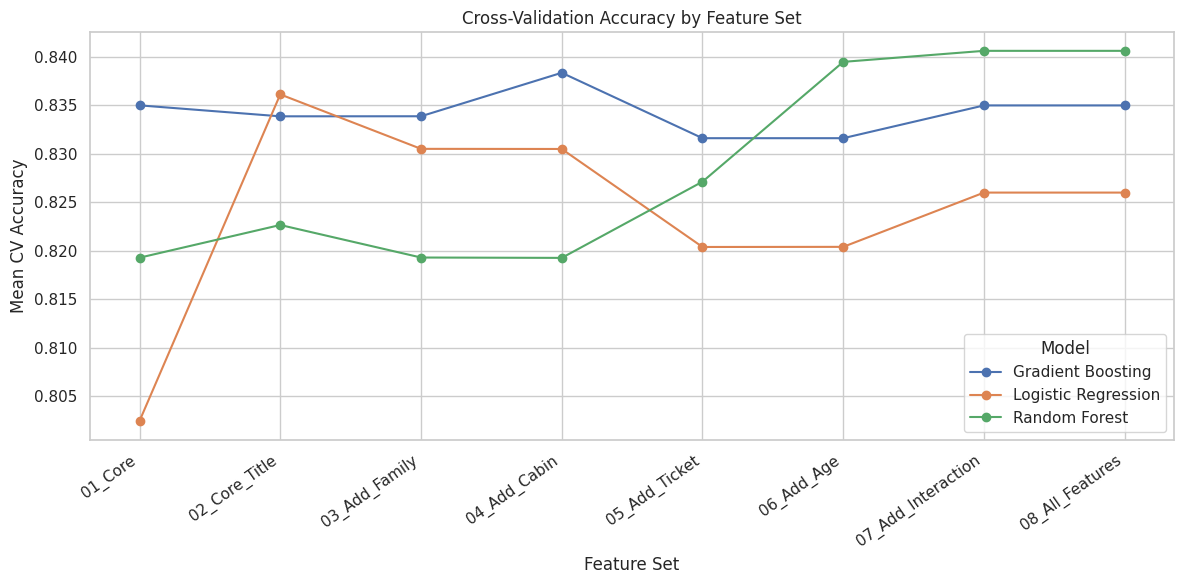

In [19]:
comparison_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title(
    "Cross-Validation Accuracy by Feature Set"
)

plt.xlabel(
    "Feature Set"
)

plt.ylabel(
    "Mean CV Accuracy"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Model"
)

plt.tight_layout()

plt.show()

# 14. Measure Progressive Feature Contribution

Because our experiments progressively add feature groups, we can calculate the change in cross-validation accuracy from one experiment to the next.

A positive change suggests that the newly added feature group improved performance for that model.

A negative change suggests that the additional features may have:

* Added noise.
* Introduced redundancy.
* Increased overfitting.
* Failed to provide useful additional information.

These results should be interpreted carefully because later experiments contain all previously added feature groups.


In [20]:
ordered_feature_sets = list(
    feature_sets.keys()
)


progressive_results = (
    ablation_df
    .pivot(
        index="Feature Set",
        columns="Model",
        values="Mean CV Accuracy"
    )
    .reindex(
        ordered_feature_sets
    )
)


progressive_change = (
    progressive_results
    .diff()
)


progressive_change.round(4)

Model,Gradient Boosting,Logistic Regression,Random Forest
Feature Set,,,
01_Core,NaN,NaN,NaN
02_Core_Title,-0.0011,0.0337,0.0034
03_Add_Family,0.0000,-0.0056,-0.0034
04_Add_Cabin,0.0045,-0.0000,-0.0000
05_Add_Ticket,-0.0067,-0.0101,0.0079
06_Add_Age,0.0000,0.0000,0.0123
07_Add_Interaction,0.0034,0.0056,0.0011
08_All_Features,0.0000,0.0000,0.0000


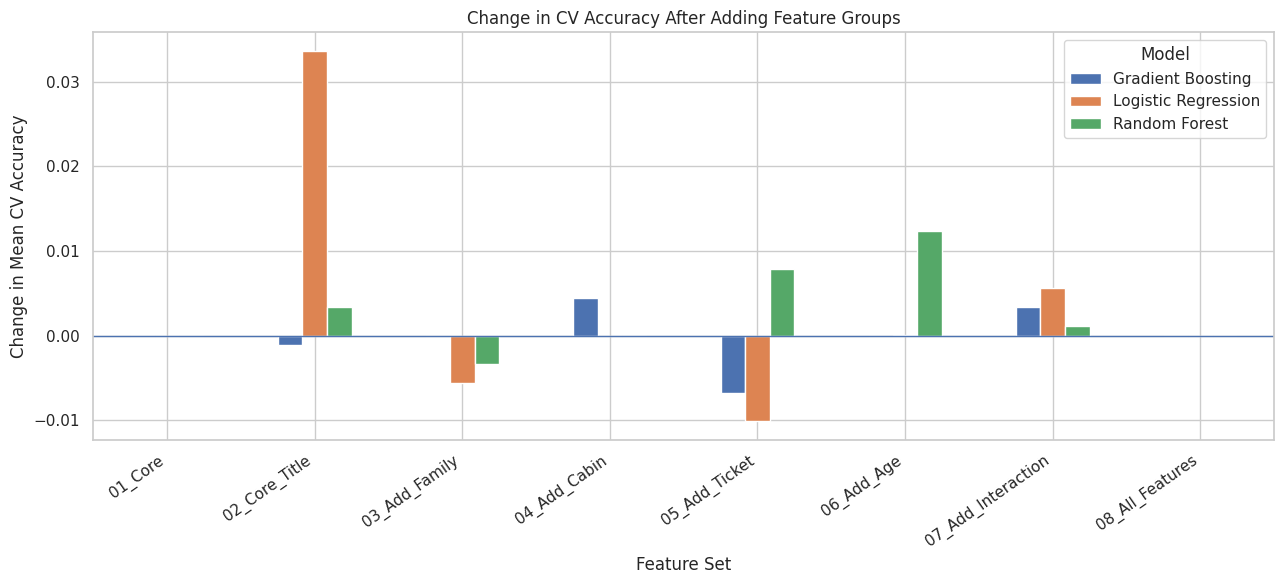

In [21]:
progressive_change.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Change in CV Accuracy After Adding Feature Groups"
)

plt.xlabel(
    "Feature Set"
)

plt.ylabel(
    "Change in Mean CV Accuracy"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()

# 15. Compare Every Feature Set Against the Core Baseline

Progressive changes show what happens when one feature group is added after another.

We also want to compare every feature set directly with the original core-feature baseline.

This tells us the total improvement achieved by feature engineering for each model.


In [22]:
core_scores = (
    ablation_df[
        ablation_df[
            "Feature Set"
        ] == "01_Core"
    ]
    .set_index(
        "Model"
    )[
        "Mean CV Accuracy"
    ]
)


ablation_df[
    "Improvement vs Core"
] = (
    ablation_df.apply(
        lambda row:
            row[
                "Mean CV Accuracy"
            ]
            -
            core_scores[
                row["Model"]
            ],
        axis=1
    )
)


ablation_df[
    [
        "Feature Set",
        "Model",
        "Mean CV Accuracy",
        "Improvement vs Core"
    ]
].sort_values(
    "Improvement vs Core",
    ascending=False
).round(4)

,Feature Set,Model,Mean CV Accuracy,Improvement vs Core
4,02_Core_Title,Logistic Regression,0.8361,0.0337
12,03_Add_Family,Logistic Regression,0.8305,0.0280
13,04_Add_Cabin,Logistic Regression,0.8305,0.0280
15,07_Add_Interaction,Logistic Regression,0.8260,0.0235
16,08_All_Features,Logistic Regression,0.8260,0.0235
0,07_Add_Interaction,Random Forest,0.8406,0.0213
1,08_All_Features,Random Forest,0.8406,0.0213
2,06_Add_Age,Random Forest,0.8395,0.0202
18,06_Add_Age,Logistic Regression,0.8204,0.0179
19,05_Add_Ticket,Logistic Regression,0.8204,0.0179


# 16. Group Removal Ablation

Progressive feature addition is useful, but it has an important limitation.

The measured contribution of a feature group may depend on the order in which groups were added.


In [23]:
model_average_scores = (
    ablation_df
    .groupby(
        "Model"
    )[
        "Mean CV Accuracy"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)


removal_model_name = (
    model_average_scores
    .index[0]
)


removal_model = (
    models[
        removal_model_name
    ]
)


print(
    f"Model selected for removal ablation: "
    f"{removal_model_name}"
)

print(
    "\nAverage CV scores:"
)

print(
    model_average_scores.round(4)
)

Model selected for removal ablation: Gradient Boosting

Average CV scores:
Model
Gradient Boosting      0.8343
Random Forest          0.8286
Logistic Regression    0.8241
Name: Mean CV Accuracy, dtype: float64


In [24]:
removal_feature_sets = {

    "All Features":
        all_candidate_features,

    "Without Title":
        [
            feature
            for feature
            in all_candidate_features
            if feature
            not in title_features
        ],

    "Without Family":
        [
            feature
            for feature
            in all_candidate_features
            if feature
            not in family_features
        ],

    "Without Cabin":
        [
            feature
            for feature
            in all_candidate_features
            if feature
            not in cabin_features
        ],

    "Without Ticket":
        [
            feature
            for feature
            in all_candidate_features
            if feature
            not in ticket_features
        ],

    "Without Age":
        [
            feature
            for feature
            in all_candidate_features
            if feature
            not in age_features
        ],

    "Without Interaction":
        [
            feature
            for feature
            in all_candidate_features
            if feature
            not in interaction_features
        ]
}


for name, features in (
    removal_feature_sets.items()
):

    print(
        f"{name:<22}: "
        f"{len(features)} features"
    )

All Features          : 21 features
Without Title         : 20 features
Without Family        : 18 features
Without Cabin         : 19 features
Without Ticket        : 17 features
Without Age           : 18 features
Without Interaction   : 20 features


In [25]:
removal_results = []


for experiment_name, selected_features in (
    removal_feature_sets.items()
):

    X = train[
        selected_features
    ].copy()


    preprocessor = (
        create_preprocessor(
            selected_features
        )
    )


    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                removal_model
            )
        ]
    )


    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )


    removal_results.append({

        "Experiment":
            experiment_name,

        "N Features":
            len(
                selected_features
            ),

        "Mean CV Accuracy":
            scores[
                "test_score"
            ].mean(),

        "CV Std":
            scores[
                "test_score"
            ].std(),

        "Train Accuracy":
            scores[
                "train_score"
            ].mean(),

        "Train-CV Gap":
            scores[
                "train_score"
            ].mean()
            -
            scores[
                "test_score"
            ].mean()
    })


removal_df = pd.DataFrame(
    removal_results
)


removal_df.round(4)

,Experiment,N Features,Mean CV Accuracy,CV Std,Train Accuracy,Train-CV Gap
0,All Features,21,0.8350,0.0159,0.9172,0.0822
1,Without Title,20,0.8395,0.0196,0.9116,0.0721
2,Without Family,18,0.8372,0.0153,0.9167,0.0794
3,Without Cabin,19,0.8316,0.0135,0.9111,0.0794
4,Without Ticket,17,0.8395,0.0199,0.9057,0.0662
5,Without Age,18,0.8406,0.0178,0.9164,0.0758
6,Without Interaction,20,0.8316,0.0158,0.9189,0.0873


In [26]:
all_features_score = (
    removal_df.loc[
        removal_df[
            "Experiment"
        ] == "All Features",
        "Mean CV Accuracy"
    ]
    .iloc[0]
)


removal_df[
    "Change vs All"
] = (
    removal_df[
        "Mean CV Accuracy"
    ]
    -
    all_features_score
)


removal_df.sort_values(
    "Change vs All",
    ascending=False
).round(4)

,Experiment,N Features,Mean CV Accuracy,CV Std,Train Accuracy,Train-CV Gap,Change vs All
5,Without Age,18,0.8406,0.0178,0.9164,0.0758,0.0056
4,Without Ticket,17,0.8395,0.0199,0.9057,0.0662,0.0045
1,Without Title,20,0.8395,0.0196,0.9116,0.0721,0.0045
2,Without Family,18,0.8372,0.0153,0.9167,0.0794,0.0022
0,All Features,21,0.8350,0.0159,0.9172,0.0822,0.0000
3,Without Cabin,19,0.8316,0.0135,0.9111,0.0794,-0.0034
6,Without Interaction,20,0.8316,0.0158,0.9189,0.0873,-0.0034


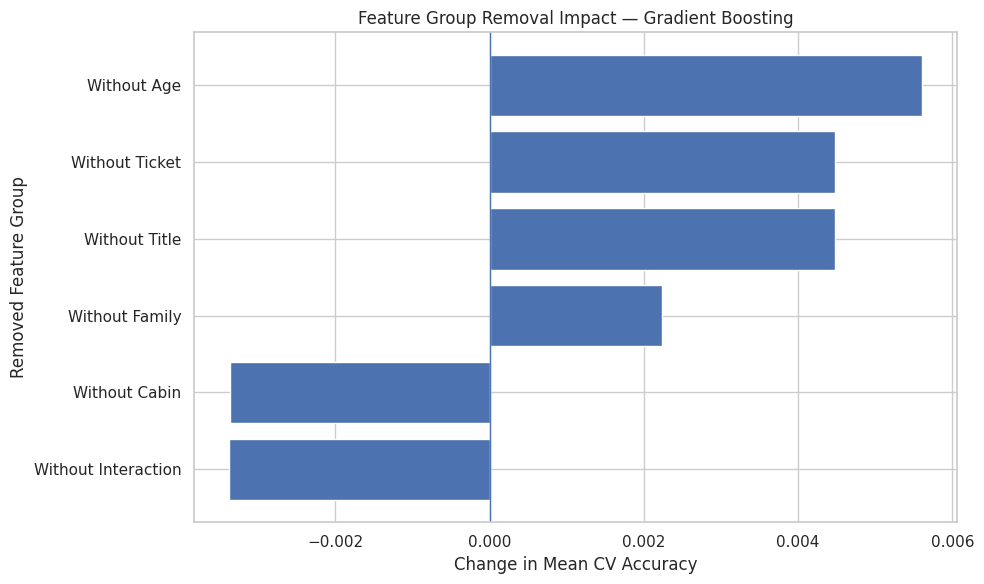

In [27]:
removal_plot = (
    removal_df[
        removal_df[
            "Experiment"
        ] != "All Features"
    ]
    .sort_values(
        "Change vs All"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.barh(
    removal_plot[
        "Experiment"
    ],
    removal_plot[
        "Change vs All"
    ]
)


plt.axvline(
    0,
    linewidth=1
)


plt.title(
    f"Feature Group Removal Impact — "
    f"{removal_model_name}"
)


plt.xlabel(
    "Change in Mean CV Accuracy"
)


plt.ylabel(
    "Removed Feature Group"
)


plt.tight_layout()

plt.show()

# 17. Identify the Best Feature Set for Each Model

Different model families may benefit from different feature representations.

For example:

* Logistic Regression may benefit from explicit interaction features.
* Tree models may learn interactions automatically.
* Highly correlated engineered features may affect linear and tree models differently.

Therefore, instead of assuming that one universal feature set is optimal, we will identify the strongest feature set for each model.


In [28]:
best_per_model = (
    ablation_df
    .sort_values(
        "Mean CV Accuracy",
        ascending=False
    )
    .groupby(
        "Model",
        as_index=False
    )
    .first()
)


best_per_model[
    [
        "Model",
        "Feature Set",
        "N Features",
        "Mean CV Accuracy",
        "CV Std",
        "Train-CV Gap",
        "Improvement vs Core"
    ]
].round(4)

,Model,Feature Set,N Features,Mean CV Accuracy,CV Std,Train-CV Gap,Improvement vs Core
0,Gradient Boosting,04_Add_Cabin,13,0.8384,0.0188,0.0688,0.0034
1,Logistic Regression,02_Core_Title,8,0.8361,0.0098,-0.0028,0.0337
2,Random Forest,07_Add_Interaction,21,0.8406,0.0099,0.1521,0.0213


In [29]:
best_feature_sets = {}


for _, row in (
    best_per_model.iterrows()
):

    model_name = row[
        "Model"
    ]

    feature_set_name = row[
        "Feature Set"
    ]

    best_feature_sets[
        model_name
    ] = feature_sets[
        feature_set_name
    ]


for model_name, features in (
    best_feature_sets.items()
):

    print(
        "\n"
        + "=" * 60
    )

    print(
        model_name
    )

    print(
        "=" * 60
    )

    for feature in features:

        print(
            f"- {feature}"
        )


Gradient Boosting
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked
- Title
- FamilySize
- IsAlone
- FamilyCategory
- CabinKnown
- Deck

Logistic Regression
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked
- Title

Random Forest
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked
- Title
- FamilySize
- IsAlone
- FamilyCategory
- CabinKnown
- Deck
- TicketGroupSize
- TicketPrefix
- FarePerPerson
- LogFare
- AgeMissing
- IsChild
- AgeGroup
- Sex_Pclass


# 18. Evaluate Performance Stability

Mean cross-validation accuracy alone is not enough to judge an experiment.

A feature set with very high average performance but large variation across folds may be less reliable than a slightly lower-scoring but more stable alternative.

We will examine the relationship between:

* Mean cross-validation accuracy.
* Cross-validation standard deviation.

The strongest candidates should ideally combine:

* High mean accuracy.
* Low variability.
* Reasonable training-validation gap.


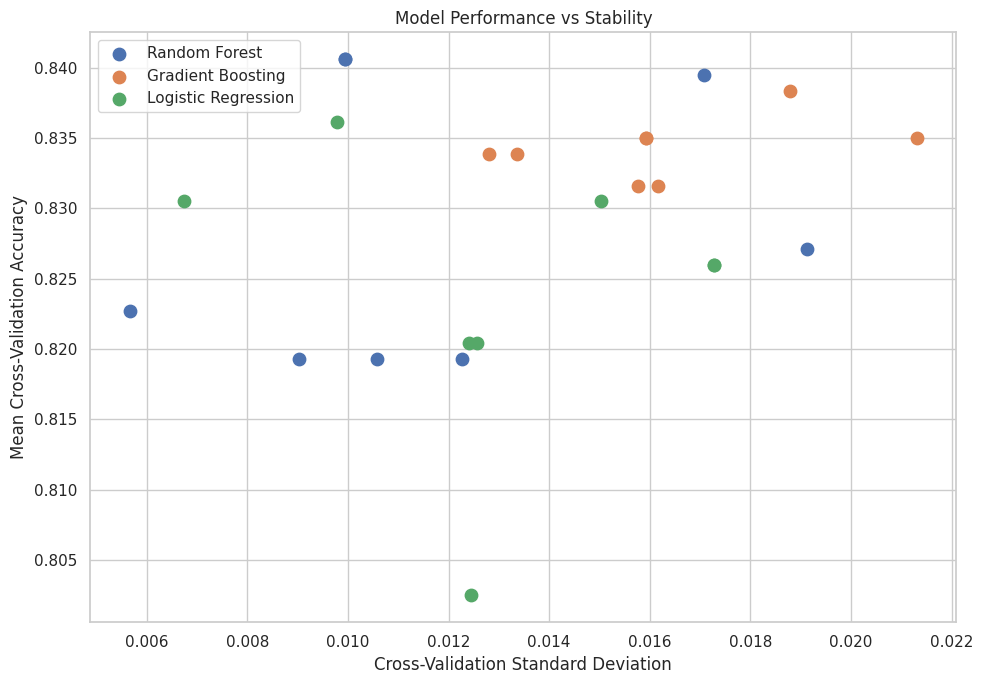

In [31]:
plt.figure(
    figsize=(10, 7)
)


for model_name in (
    ablation_df[
        "Model"
    ].unique()
):

    subset = (
        ablation_df[
            ablation_df[
                "Model"
            ] == model_name
        ]
    )


    plt.scatter(
        subset[
            "CV Std"
        ],
        subset[
            "Mean CV Accuracy"
        ],
        label=model_name,
        s=80
    )


plt.xlabel(
    "Cross-Validation Standard Deviation"
)

plt.ylabel(
    "Mean Cross-Validation Accuracy"
)

plt.title(
    "Model Performance vs Stability"
)

plt.legend()

plt.tight_layout()

plt.show()

# 19. Save Feature Ablation Results

The results of this notebook will be saved for future comparison.

We will save:

1. Progressive feature-ablation results.
2. Feature-group removal results.
3. The best feature set identified for each model.

These files will provide a record of our feature-selection decisions before hyperparameter tuning.


In [32]:
results_dir = Path(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)


ablation_df.to_csv(
    results_dir /
    "feature_ablation_results.csv",
    index=False
)


removal_df.to_csv(
    results_dir /
    "feature_removal_results.csv",
    index=False
)


best_per_model.to_csv(
    results_dir /
    "best_feature_sets_by_model.csv",
    index=False
)


print(
    "Feature ablation results saved successfully."
)

Feature ablation results saved successfully.


# 20. Phase 6 Summary

In this notebook, we systematically evaluated the engineered features created during Phase 4.

Rather than assuming that every engineered feature improves prediction, we tested feature groups using controlled cross-validation experiments.

---

## Progressive Feature Ablation

We started with the original core Titanic predictors:

* `Pclass`
* `Sex`
* `Age`
* `SibSp`
* `Parch`
* `Fare`
* `Embarked`

We then progressively introduced:

1. Title features.
2. Family features.
3. Cabin features.
4. Ticket and fare features.
5. Additional age features.
6. Interaction features.

Each feature set was evaluated using:

* Logistic Regression.
* Random Forest.
* Gradient Boosting.

All experiments used identical Stratified 5-Fold Cross-Validation splits.

---

## Feature Group Removal

Progressive addition alone can be affected by the order in which features are introduced.

To strengthen our analysis, we also started with the complete engineered feature set and removed one feature group at a time.

This helped identify whether individual groups were:

* Providing useful information.
* Redundant with other variables.
* Introducing noise.

---

## Model-Specific Feature Selection

We also identified the strongest feature set separately for each model family.

This is important because different algorithms learn relationships differently.

Linear models may benefit from explicitly engineered interactions, while tree-based models can often discover nonlinear relationships automatically.


The final goal is not simply to build the most complex model.

The goal is to build a model whose improvements are supported by reliable experimental evidence.
